# Download global DEM data

This notebook downloads and crops either the **SRTM1 30 m DEM** or the **Copernicus DEM GLO-30** to the bounding box of a user-defined area of interest (AOI).

The detailed download, tile-selection, mosaicking, cropping, metadata-reporting, and plotting functions are stored in `global_dem_downloader.py` to keep the notebook concise and reproducible.

In [1]:
from pathlib import Path

from global_dem_downloader import (
    download_srtm,
    download_copernicus,
)

## User inputs

Set the AOI vector path and the output directory. The AOI must contain a valid coordinate reference system.

In [2]:
AOI_PATH = Path("/mnt/summer/USERS/KOAI/Cosmo-SkyMed/shapefile/AOI.shp")

OUTPUT_DIR = Path("/mnt/summer/USERS/KOAI/Cosmo-SkyMed/reference_DEMs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DEM = True

## SRTM1 30 m

The default buffer is `0.00°`, matching the original workflow. Increase it when additional DEM coverage is required around the AOI.

AOI bounds in WGS84:
min_lon = 6.059465
min_lat = 44.784932
max_lon = 6.460641
max_lat = 45.059812

Required SRTM tiles:
N44E006  lower-left: lat=44, lon=6
N45E006  lower-left: lat=45, lon=6
Using cached tile: /mnt/summer/USERS/KOAI/Cosmo-SkyMed/reference_DEMs/SRTM_ref/hgt_tiles/N44E006.hgt.gz
Using cached tile: /mnt/summer/USERS/KOAI/Cosmo-SkyMed/reference_DEMs/SRTM_ref/hgt_tiles/N45E006.hgt.gz

Mosaicking and cropping to AOI bounds...

Saved SRTM 30 m DEM:
/mnt/summer/USERS/KOAI/Cosmo-SkyMed/reference_DEMs/SRTM_ref/SRTM1_30m.tif

Output DEM information:
CRS: EPSG:4326
Width: 1444
Height: 990
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Bounds: BoundingBox(left=6.059465403984135, bottom=44.78481171417685, right=6.460576515095246, top=45.059811714176845)
NoData: -32768.0
Data type: int16
Min elevation: 723.00 m
Max elevation: 4025.00 m
Mean elevation: 2305.11 m


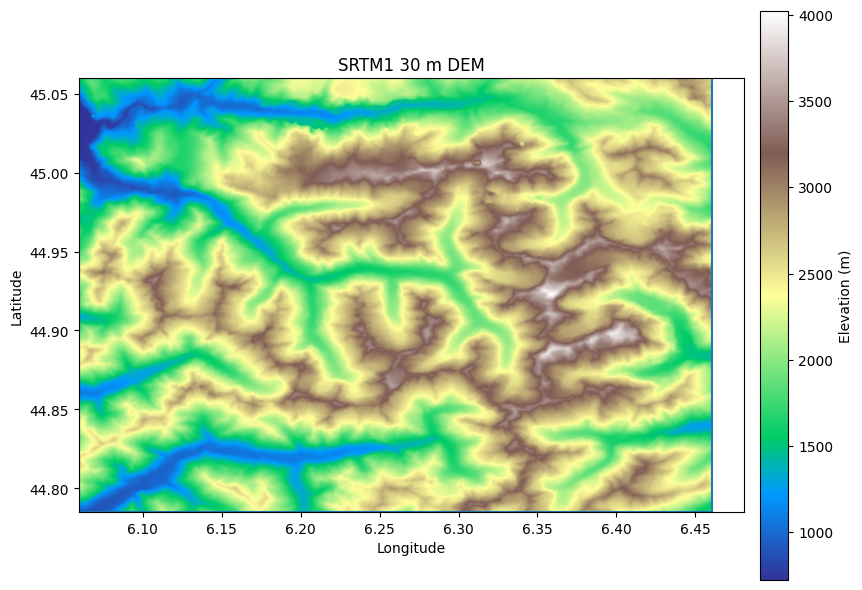

In [5]:
srtm_path = download_srtm(
    aoi_path=AOI_PATH,
    out_tif=OUTPUT_DIR / "SRTM_ref" / "SRTM1_30m.tif",
    buffer_deg=0.00,
    plot=PLOT_DEM,
)

## Copernicus DEM GLO-30

The default buffer is `0.05°`, matching the original workflow and providing additional terrain coverage around the AOI.

Buffered AOI bounds in WGS84:
min_lon = 6.009465
min_lat = 44.734932
max_lon = 6.510641
max_lat = 45.109812

Required Copernicus DEM GLO-30 tiles:
Copernicus_DSM_COG_10_N44_00_E006_00_DEM
Copernicus_DSM_COG_10_N45_00_E006_00_DEM
Downloading:
https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N44_00_E006_00_DEM/Copernicus_DSM_COG_10_N44_00_E006_00_DEM.tif
Downloading:
https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N45_00_E006_00_DEM/Copernicus_DSM_COG_10_N45_00_E006_00_DEM.tif

Mosaicking and cropping Copernicus DEM...

Saved Copernicus DEM:
/mnt/summer/USERS/KOAI/Cosmo-SkyMed/reference_DEMs/Copernicus_ref/Copernicus_GLO30_30m.tif

Output DEM information:
CRS: EPSG:4326
Width: 1804
Height: 1350
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Bounds: BoundingBox(left=6.0094654039841355, bottom=44.73481171417684, right=6.510576515095247, top=45.10981171417684)
NoData: None
Data type: float32
Min elevation: 0.00 m
Max elevation: 4021.10 m
Mean e

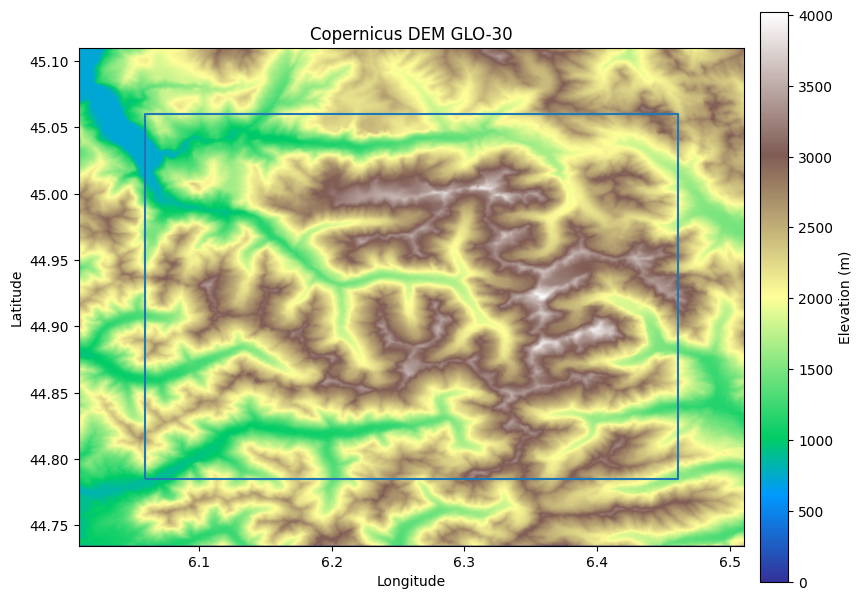

In [4]:
copernicus_path = download_copernicus(
    aoi_path=AOI_PATH,
    out_tif=OUTPUT_DIR / "Copernicus_ref" / "Copernicus_GLO30_30m.tif",
    buffer_deg=0.05,
    plot=PLOT_DEM,
)